In [ ]:
using Pkg
Pkg.activate(normpath(@__DIR__, ".."))

In [2]:
using JLD2

include(normpath(joinpath(@__DIR__, "..", "utils", "utils.jl")))

In [3]:
function scatter_plot(ax, rn_met, label_pos, time_type; axis_log=true)
    
    if time_type == "on"
        x_data = [m.truet_mean[1] for m in rn_met]
        y_data = [m.binart_mean[1] for m in rn_met]
    elseif time_type == "off"
        x_data = [m.truet_mean[2] for m in rn_met]
        y_data = [m.binart_mean[2] for m in rn_met]
    end
    
    sc = ax.scatter(x_data, y_data, s=8, c="#6baed6", alpha=0.6)  # Reduce marker size and add transparency
    sc.set_rasterized(true)
        
    x_min, x_max = minimum(vcat(x_data,y_data)), maximum(vcat(x_data,y_data))
    ax.plot(x_min*0.9:0.1:x_max*1.1, x_min*0.9:0.1:x_max*1.1, c="#2c7bb6", linestyle="--", linewidth=1.5)
    
    ax.set_xlim(x_min * 0.8, x_max * 1.15)
    ax.set_ylim(x_min * 0.8, x_max * 1.15)
    
    wd = 1.2
    ax.tick_params(axis="both", labelsize=11, width=wd)
    ax.tick_params(which="minor", width=wd*0.9)
    
    for spine in values(ax.spines)
        spine.set_linewidth(wd)
    end
    
    # Compute correlation
    acc = round(mean([m.acc for m in rn_met]),digits=3)
    #mre = round(mean(abs.(y_data .- x_data)./x_data),digits=3)
    ax.text(label_pos..., L"\langle \alpha \rangle =" * string(acc), transform=ax.transAxes, fontsize=11, 
    bbox=Dict(:facecolor => "white", :edgecolor => "#bdbdbd", :alpha => 0.8, :boxstyle  => "round,pad=0.5", :linewidth => 1.2))  # Improve visibility
    
    if axis_log
        ax.set_xscale("log")
        ax.set_yscale("log")
    end
end;

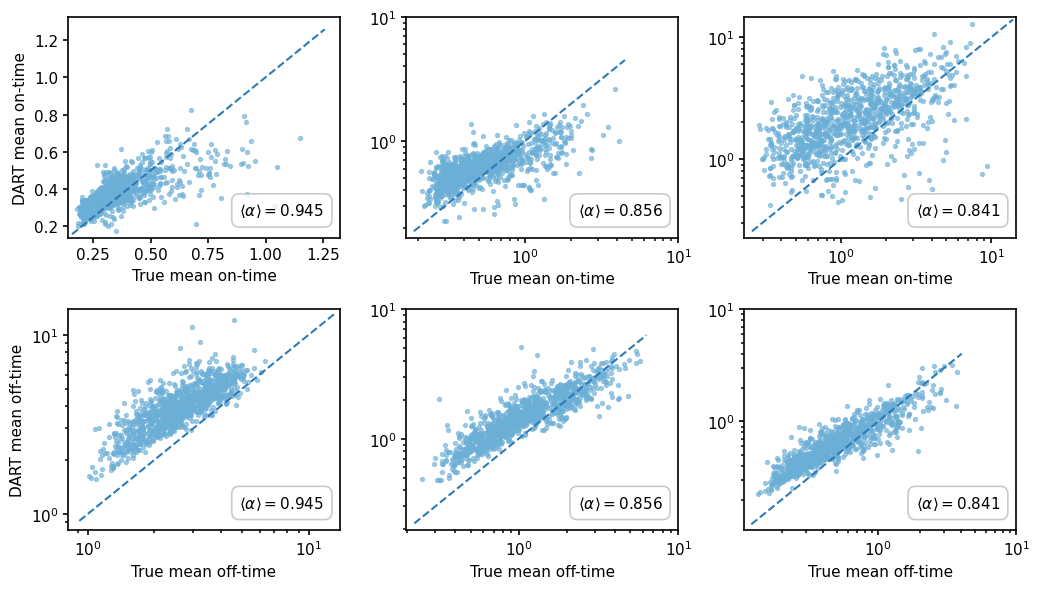

In [5]:
data_dir = "synthetic_data/real_cv1_data_res";
# define directory for files
files_cv1 = [
    (joinpath(data_dir, "ngen_dlb_compare_seed_1.jld2"),  "b1"),   # col 1
    (joinpath(data_dir, "ngen_dlnb1_compare_seed_1.jld2"), "nb1"), # col 2
    (joinpath(data_dir, "ngen_dlnb0_compare_seed_1.jld2"), "nb0"), # col 3
]

# load files
rn_met_list = []
for (file, _) in files_cv1
    @load file rn_met_dl
    push!(rn_met_list, copy(rn_met_dl))
end

# plot
fig, axs = plt.subplots(2, 3, figsize=(10.5, 6.0))  # 2 rows = on/off, 3 cols = model
axis_log = true

for j in 1:3
    rn_met = rn_met_list[j]
    for i in 1:2
        if i == 1 && j == 1
            scatter_plot(axs[i, j], rn_met, (0.63, 0.1), "on"; axis_log=false)
        elseif i == 1
            scatter_plot(axs[i, j], rn_met, (0.63, 0.1), "on"; axis_log=axis_log)
        elseif i == 2
            scatter_plot(axs[i, j], rn_met, (0.63, 0.1), "off"; axis_log=axis_log)
        end
    end
    axs[1,j].set_xlabel("True mean on-time",fontsize=11)
    axs[2,j].set_xlabel("True mean off-time",fontsize=11)
end

axs[1, 1].set_ylabel("DART mean on-time",fontsize=11)
axs[2, 1].set_ylabel("DART mean off-time",fontsize=11)

#targets = (axs[3,2], axs[3,4])   
for ax in axs
    if String(ax[:get_yscale]()) == "log"
        auto_min, auto_max = ax[:get_ylim]()
        new_min = auto_min
        new_max = max(auto_max, 10.0^1)   
        ax[:set_ylim]([new_min, new_max])

        ax[:get_yaxis]()[:set_major_formatter](
            plt[:FuncFormatter]((v,p)->"\$10^{$(Int(round(log10(v))))}\$")
        )
    end
    
    if String(ax[:get_xscale]()) == "log"
        x0, x1 = ax[:get_xlim]()
        ax[:set_xlim]([x0, max(x1, 10.0^1)])
    end
end

plt.tight_layout()

fig.savefig("figs/DL_cv1.pdf", bbox_inches="tight", dpi = 800);

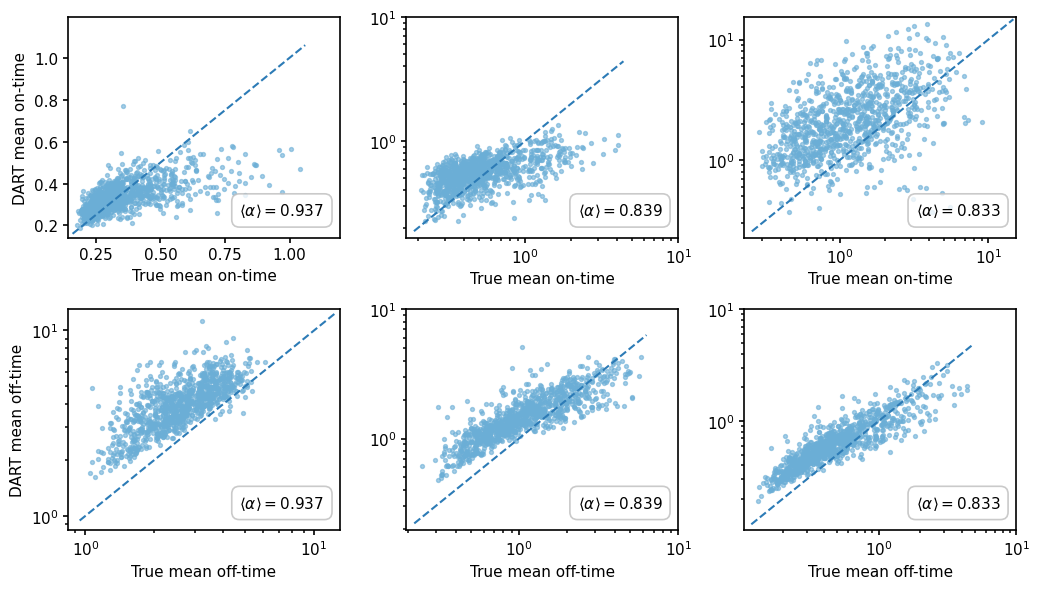

In [7]:
data_dir = "synthetic_data/real_cv2_data_res";

files_cv2 = [
    (joinpath(data_dir, "ngen_dlb_compare_seed_1.jld2"),  "b1"),   # col 1
    (joinpath(data_dir, "ngen_dlnb1_compare_seed_1.jld2"), "nb1"), # col 2
    (joinpath(data_dir, "ngen_dlnb0_compare_seed_1.jld2"), "nb0"), # col 3
]

# load files
rn_met_list = []
for (file, _) in files_cv2
    @load file rn_met_dl
    push!(rn_met_list, copy(rn_met_dl))
end

# plot
fig, axs = plt.subplots(2, 3, figsize=(10.5, 6.0))  # 2 rows = on/off, 3 cols = model
axis_log = true

for j in 1:3
    rn_met = rn_met_list[j]
    for i in 1:2
        if i == 1 && j == 1
            scatter_plot(axs[i, j], rn_met, (0.63, 0.1), "on"; axis_log=false)
        elseif i == 1
            scatter_plot(axs[i, j], rn_met, (0.63, 0.1), "on"; axis_log=axis_log)
        elseif i == 2
            scatter_plot(axs[i, j], rn_met, (0.63, 0.1), "off"; axis_log=axis_log)
        end
    end
    axs[1,j].set_xlabel("True mean on-time",fontsize=11)
    axs[2,j].set_xlabel("True mean off-time",fontsize=11)
end

axs[1, 1].set_ylabel("DART mean on-time",fontsize=11)
axs[2, 1].set_ylabel("DART mean off-time",fontsize=11)

for ax in axs
    if String(ax[:get_yscale]()) == "log"
        auto_min, auto_max = ax[:get_ylim]()
        new_min = auto_min
        new_max = max(auto_max, 10.0^1)   
        ax[:set_ylim]([new_min, new_max])

        ax[:get_yaxis]()[:set_major_formatter](
            plt[:FuncFormatter]((v,p)->"\$10^{$(Int(round(log10(v))))}\$")
        )
    end
    
    if String(ax[:get_xscale]()) == "log"
        x0, x1 = ax[:get_xlim]()
        ax[:set_xlim]([x0, max(x1, 10.0^1)])
    end
end

plt.tight_layout()

fig.savefig("figs/DL_cv2.pdf", bbox_inches="tight",dpi = 800);